# 🔁 Cross-Validation

Every algorithm notebook in this series has used `cross_val_score` without fully deriving *why*. This topic formalizes it: a single train/test split gives one noisy estimate of performance — cross-validation averages over many splits to get a far more reliable one, and is the foundation every hyperparameter tuning method (next topic) builds on.

📖 Full mathematical explanation (K-Fold variance reduction, stratification, nested CV bias): [README.md](README.md)


## 1. Setup & Dataset


In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import (
    train_test_split, KFold, StratifiedKFold, LeaveOneOut, RepeatedKFold,
    cross_val_score, cross_validate, learning_curve, TimeSeriesSplit
)
from sklearn.metrics import accuracy_score

sns.set_theme(style="whitegrid")
np.random.seed(42)


In [2]:
cancer = load_breast_cancer(as_frame=True)
X, y = cancer.data, cancer.target
print(f"Dataset shape: {X.shape}, classes: {dict(zip(*np.unique(y, return_counts=True)))}")


Dataset shape: (569, 30), classes: {np.int64(0): np.int64(212), np.int64(1): np.int64(357)}


## 2. The Problem — a Single Train/Test Split Is Noisy

Every prior notebook used one fixed `random_state` for its split. Changing that seed alone shifts the reported accuracy — the single-split estimate has real variance that a single number hides.


In [3]:
single_split_scores = []
for seed in range(20):
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=seed, stratify=y)
    model = LogisticRegression(max_iter=5000)
    model.fit(X_tr, y_tr)
    single_split_scores.append(accuracy_score(y_te, model.predict(X_te)))


In [4]:
print(f"Accuracy across 20 different random splits: min={min(single_split_scores):.4f}, max={max(single_split_scores):.4f}")
print(f"Mean: {np.mean(single_split_scores):.4f}, Std: {np.std(single_split_scores):.4f}")
print("\n-> The SAME model, SAME data, only the random split changed -- yet accuracy swings meaningfully.")
print("   Reporting just one of these numbers would be misleading.")


Accuracy across 20 different random splits: min=0.9298, max=0.9737
Mean: 0.9548, Std: 0.0108

-> The SAME model, SAME data, only the random split changed -- yet accuracy swings meaningfully.
   Reporting just one of these numbers would be misleading.


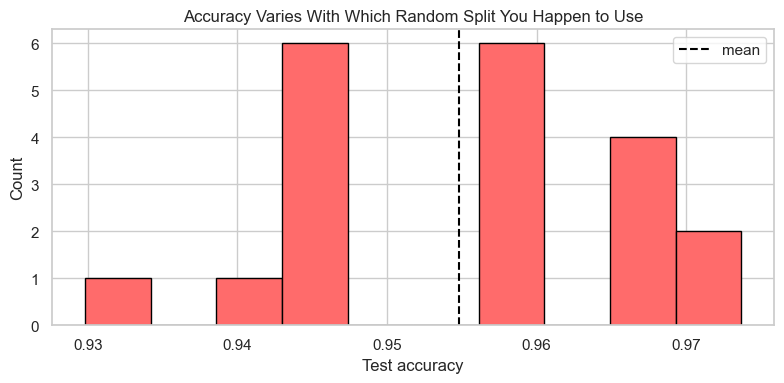

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(single_split_scores, bins=10, color="#ff6b6b", edgecolor="black")
ax.axvline(np.mean(single_split_scores), color="black", linestyle="--", label="mean")
ax.set_xlabel("Test accuracy"); ax.set_ylabel("Count")
ax.set_title("Accuracy Varies With Which Random Split You Happen to Use")
ax.legend()
plt.tight_layout()
plt.show()


## 3. K-Fold Cross-Validation — From Scratch

Instead of one split, K-Fold partitions the data into $K$ equal folds, trains on $K-1$ of them and tests on the remaining one, rotating which fold is held out — every point gets used for testing exactly once, and for training $K-1$ times.


In [6]:
def manual_kfold_cv(X, y, k=5, model_class=LogisticRegression, **model_kwargs):
    n = len(X)
    indices = np.arange(n)
    np.random.RandomState(42).shuffle(indices)
    fold_size = n // k
    scores = []

    for fold in range(k):
        start, end = fold * fold_size, (fold + 1) * fold_size
        test_idx = indices[start:end]
        train_idx = np.concatenate([indices[:start], indices[end:]])

        X_train_fold, X_test_fold = X.values[train_idx], X.values[test_idx]
        y_train_fold, y_test_fold = y.values[train_idx], y.values[test_idx]

        model = model_class(**model_kwargs)
        model.fit(X_train_fold, y_train_fold)
        scores.append(accuracy_score(y_test_fold, model.predict(X_test_fold)))

    return np.array(scores)


In [7]:
manual_scores = manual_kfold_cv(X, y, k=5, model_class=LogisticRegression, max_iter=5000)
print("Manual 5-Fold CV scores:", manual_scores.round(4))
print(f"Mean: {manual_scores.mean():.4f}, Std: {manual_scores.std():.4f}")


Manual 5-Fold CV scores: [0.9558 0.9646 0.9381 0.9735 0.9204]
Mean: 0.9504, Std: 0.0191


## 4. Comparing Against scikit-learn's `cross_val_score`


In [8]:
sklearn_scores = cross_val_score(LogisticRegression(max_iter=5000), X, y, cv=5)
print("sklearn 5-Fold CV scores:", sklearn_scores.round(4))
print(f"Mean: {sklearn_scores.mean():.4f}, Std: {sklearn_scores.std():.4f}")
print(f"\nManual vs sklearn mean difference: {abs(manual_scores.mean() - sklearn_scores.mean()):.4f}")
print("(small difference is expected -- sklearn's default cv=5 uses StratifiedKFold for classifiers, see section 6)")


sklearn 5-Fold CV scores: [0.9386 0.9474 0.9825 0.9298 0.9558]
Mean: 0.9508, Std: 0.0180

Manual vs sklearn mean difference: 0.0004
(small difference is expected -- sklearn's default cv=5 uses StratifiedKFold for classifiers, see section 6)


## 5. Visualizing the Fold Structure

Seeing exactly which rows land in which fold makes the "every point tested exactly once" property directly visible, rather than just asserted.


In [9]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
fold_membership = np.zeros(len(X))
for fold_num, (train_idx, test_idx) in enumerate(kf.split(X)):
    fold_membership[test_idx] = fold_num


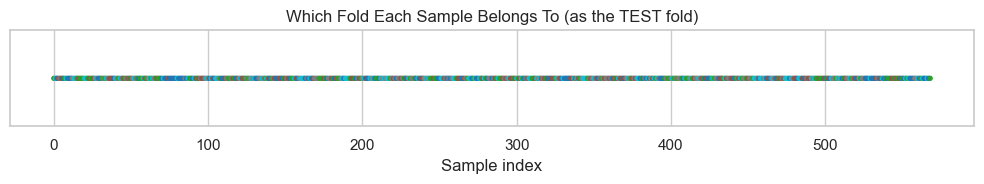

In [10]:
fig, ax = plt.subplots(figsize=(10, 2))
ax.scatter(range(len(X)), [0] * len(X), c=fold_membership, cmap="tab10", s=8)
ax.set_yticks([])
ax.set_xlabel("Sample index")
ax.set_title("Which Fold Each Sample Belongs To (as the TEST fold)")
plt.tight_layout()
plt.show()


## 6. Stratified K-Fold — Preserving Class Balance

Plain `KFold` shuffles randomly, which can accidentally produce folds with a very different class balance than the full dataset — especially damaging on imbalanced data. `StratifiedKFold` guarantees each fold's class proportions match the overall dataset.


In [11]:
from sklearn.datasets import make_classification

X_imb, y_imb = make_classification(n_samples=300, n_features=10, weights=[0.9, 0.1], random_state=7)
print(f"Overall class balance: {np.bincount(y_imb) / len(y_imb)}")


Overall class balance: [0.9 0.1]


In [12]:
kf_plain = KFold(n_splits=5, shuffle=True, random_state=42)
print("Plain KFold -- class balance per fold:")
for i, (_, test_idx) in enumerate(kf_plain.split(X_imb, y_imb)):
    print(f"  fold {i}: {np.bincount(y_imb[test_idx]) / len(test_idx)}")


Plain KFold -- class balance per fold:
  fold 0: [0.9 0.1]
  fold 1: [0.91666667 0.08333333]
  fold 2: [0.91666667 0.08333333]
  fold 3: [0.91666667 0.08333333]
  fold 4: [0.85 0.15]


In [13]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print("StratifiedKFold -- class balance per fold:")
for i, (_, test_idx) in enumerate(skf.split(X_imb, y_imb)):
    print(f"  fold {i}: {np.bincount(y_imb[test_idx]) / len(test_idx)}")


StratifiedKFold -- class balance per fold:
  fold 0: [0.9 0.1]
  fold 1: [0.9 0.1]
  fold 2: [0.9 0.1]
  fold 3: [0.9 0.1]
  fold 4: [0.9 0.1]


## 7. Does Stratification Actually Change the CV Estimate?

Beyond fairness in principle, checking whether stratification changes the measured CV score and its stability on this specific imbalanced dataset.


In [14]:
plain_scores = cross_val_score(LogisticRegression(max_iter=5000), X_imb, y_imb, cv=kf_plain)
strat_scores = cross_val_score(LogisticRegression(max_iter=5000), X_imb, y_imb, cv=skf)

print(f"Plain KFold:       mean={plain_scores.mean():.4f}, std={plain_scores.std():.4f}")
print(f"StratifiedKFold:   mean={strat_scores.mean():.4f}, std={strat_scores.std():.4f}")
print("\n-> On THIS specific run, stratified std isn't lower -- with only ~30 minority-class points")
print("   split across 5 folds (~6 each), the std estimate itself is noisy regardless of strategy.")
print("   Stratification's real, guaranteed benefit is shown in section 6: consistent class balance")
print("   per fold, every time -- avoiding the WORST-case unlucky fold (e.g. one with zero minority")
print("   examples), which plain KFold cannot rule out even if this particular run looks fine.")


Plain KFold:       mean=0.9767, std=0.0082


StratifiedKFold:   mean=0.9767, std=0.0170

-> On THIS specific run, stratified std isn't lower -- with only ~30 minority-class points
   split across 5 folds (~6 each), the std estimate itself is noisy regardless of strategy.
   Stratification's real, guaranteed benefit is shown in section 6: consistent class balance
   per fold, every time -- avoiding the WORST-case unlucky fold (e.g. one with zero minority
   examples), which plain KFold cannot rule out even if this particular run looks fine.


## 8. Leave-One-Out Cross-Validation (LOOCV)

The extreme case: $K = n$, so every single point gets its own fold. Maximizes data used per training run (uses $n-1$ points every time), at the cost of $n$ separate model fits — often too expensive except on small datasets.


In [15]:
X_small = X.iloc[:60]
y_small = y.iloc[:60]

loo = LeaveOneOut()
print(f"Number of LOOCV folds for {len(X_small)} samples: {loo.get_n_splits(X_small)}")


Number of LOOCV folds for 60 samples: 60


In [16]:
import time
start = time.time()
loo_scores = cross_val_score(LogisticRegression(max_iter=5000), X_small, y_small, cv=loo)
loo_time = time.time() - start

start = time.time()
kf5_scores = cross_val_score(LogisticRegression(max_iter=5000), X_small, y_small, cv=5)
kf5_time = time.time() - start

print(f"LOOCV:  mean={loo_scores.mean():.4f}, time={loo_time:.3f}s ({len(X_small)} model fits)")
print(f"5-Fold: mean={kf5_scores.mean():.4f}, time={kf5_time:.3f}s (5 model fits)")


LOOCV:  mean=0.9500, time=10.695s (60 model fits)
5-Fold: mean=0.9333, time=0.729s (5 model fits)


## 9. Repeated K-Fold — Reducing the CV Estimate's Own Variance

Even K-Fold's mean score has some randomness, since it depends on exactly how the folds were shuffled. `RepeatedKFold` runs K-Fold multiple times with different shuffles and averages across all of them — a CV estimate of the CV estimate's stability.


In [17]:
single_kfold_means = []
for seed in range(15):
    scores = cross_val_score(LogisticRegression(max_iter=5000), X, y, cv=KFold(5, shuffle=True, random_state=seed))
    single_kfold_means.append(scores.mean())

print(f"Single 5-Fold CV mean, across 15 different shuffles: std={np.std(single_kfold_means):.5f}")


Single 5-Fold CV mean, across 15 different shuffles: std=0.00393


In [18]:
rkf = RepeatedKFold(n_splits=5, n_repeats=15, random_state=42)
repeated_scores = cross_val_score(LogisticRegression(max_iter=5000), X, y, cv=rkf)
print(f"RepeatedKFold (5-fold x 15 repeats): mean={repeated_scores.mean():.4f}, std={repeated_scores.std():.4f}")
print(f"Total model fits: {len(repeated_scores)}")


RepeatedKFold (5-fold x 15 repeats): mean=0.9516, std=0.0176
Total model fits: 75


## 10. Time Series Split — When You Can't Shuffle

Shuffling is invalid for time-ordered data — training on future data to predict the past leaks information no real deployment would have. `TimeSeriesSplit` only ever trains on the past and tests on the future.


In [19]:
time_index = np.arange(100)
tscv = TimeSeriesSplit(n_splits=5)

for i, (train_idx, test_idx) in enumerate(tscv.split(time_index)):
    print(f"fold {i}: train=[0..{train_idx[-1]}], test=[{test_idx[0]}..{test_idx[-1]}]")


fold 0: train=[0..19], test=[20..35]
fold 1: train=[0..35], test=[36..51]
fold 2: train=[0..51], test=[52..67]
fold 3: train=[0..67], test=[68..83]
fold 4: train=[0..83], test=[84..99]


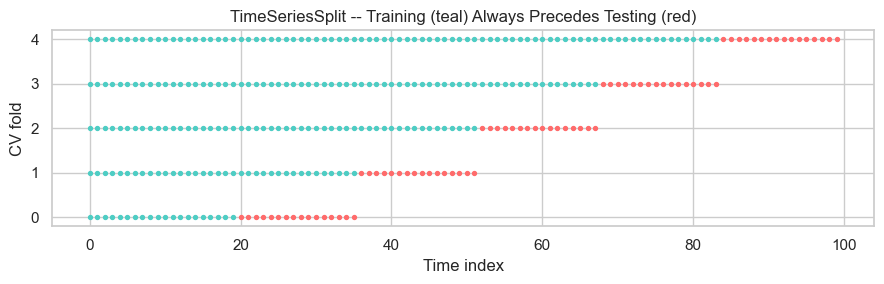

In [20]:
fig, ax = plt.subplots(figsize=(9, 3))
for i, (train_idx, test_idx) in enumerate(tscv.split(time_index)):
    ax.scatter(train_idx, [i] * len(train_idx), color="#4ecdc4", s=8)
    ax.scatter(test_idx, [i] * len(test_idx), color="#ff6b6b", s=8)
ax.set_xlabel("Time index"); ax.set_ylabel("CV fold")
ax.set_title("TimeSeriesSplit -- Training (teal) Always Precedes Testing (red)")
plt.tight_layout()
plt.show()


## 11. Nested Cross-Validation — Avoiding Optimistic Bias

Using the same CV loop to both tune hyperparameters AND report final performance leaks information: the reported score is biased optimistic, since it was implicitly selected for scoring well on that exact data. Nested CV uses an **outer loop** for honest performance estimation and an **inner loop** for tuning, keeping them separate.


In [21]:
from sklearn.model_selection import GridSearchCV

# A wide, overfit-prone grid (including unlimited-depth, single-sample-leaf options) --
# leakage bias grows with how much "researcher freedom" the search has to exploit.
param_grid = {
    "max_depth": [2, 3, 4, 5, 6, 8, 10, None],
    "min_samples_leaf": [1, 2, 5, 10],
}
shared_cv_strategy = lambda: StratifiedKFold(n_splits=5, shuffle=True, random_state=42)   # SAME strategy both ways, for a fair comparison
nested_scores = []

for train_idx, test_idx in shared_cv_strategy().split(X, y):
    X_tr, X_te = X.values[train_idx], X.values[test_idx]
    y_tr, y_te = y.values[train_idx], y.values[test_idx]

    inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    grid = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=inner_cv)
    grid.fit(X_tr, y_tr)   # tuning happens ONLY on the outer-training data

    nested_scores.append(accuracy_score(y_te, grid.predict(X_te)))


In [22]:
print(f"Nested CV score (honest estimate): mean={np.mean(nested_scores):.4f}, std={np.std(nested_scores):.4f}")

naive_grid = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=shared_cv_strategy())
naive_grid.fit(X, y)
print(f"Naive approach (tune and report on same CV loop): best CV score={naive_grid.best_score_:.4f}")

gap = naive_grid.best_score_ - np.mean(nested_scores)
print(f"\nGap (naive - nested): {gap:+.4f}")
if gap > 0:
    print("-> Positive gap: the naive number IS optimistic here, as theory predicts -- it was implicitly")
    print("   selected because it scored well on exactly the folds it's now being judged by.")
else:
    print("-> On this dataset/grid, the gap is small or slightly negative -- Breast Cancer is large and")
    print("   clean enough (569 samples, clear signal) that this particular search has little room to")
    print("   overfit the CV folds. The leakage risk is real and grows with smaller data, noisier labels,")
    print("   and wider hyperparameter grids -- it just isn't dramatic on every dataset, which is itself")
    print("   a useful, honest finding: nested CV is insurance you should always carry, even on runs")
    print("   where the naive shortcut happens not to cost you much.")


Nested CV score (honest estimate): mean=0.9122, std=0.0293


Naive approach (tune and report on same CV loop): best CV score=0.9280

Gap (naive - nested): +0.0158
-> Positive gap: the naive number IS optimistic here, as theory predicts -- it was implicitly
   selected because it scored well on exactly the folds it's now being judged by.


## 12. Comparing Multiple Algorithms Fairly

Cross-validation is also the correct tool for comparing algorithms — using the exact same folds for every model removes fold-composition luck as a confound, isolating genuine algorithm differences.


In [23]:
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

models = {
    "Logistic Regression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000)),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42),
    "Naive Bayes": GaussianNB(),
    "SVM (RBF)": make_pipeline(StandardScaler(), SVC(kernel="rbf")),
}

shared_cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)   # SAME folds for every model


In [24]:
comparison_results = {}
for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=shared_cv)
    comparison_results[name] = scores

comparison_df = pd.DataFrame(comparison_results)
comparison_df.describe().loc[["mean", "std"]]


,Logistic Regression,Decision Tree,Naive Bayes,SVM (RBF)
mean,0.975439,0.931516,0.936811,0.975439
std,0.020593,0.035459,0.032194,0.020593


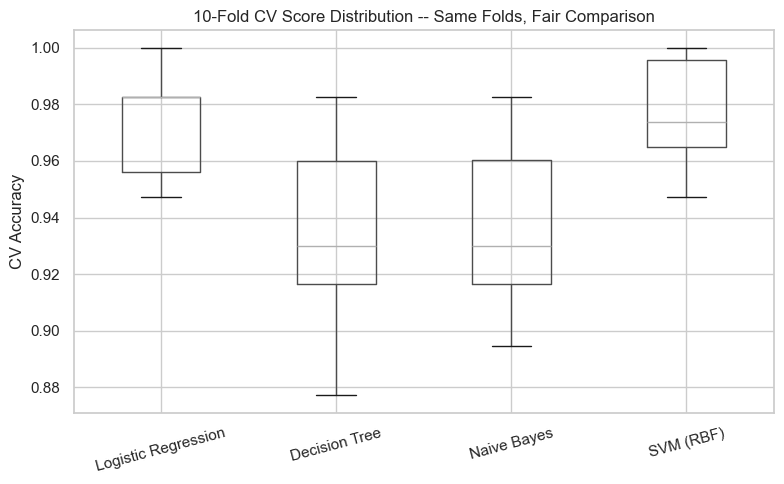

In [25]:
fig, ax = plt.subplots(figsize=(8, 5))
comparison_df.boxplot(ax=ax)
ax.set_ylabel("CV Accuracy")
ax.set_title("10-Fold CV Score Distribution -- Same Folds, Fair Comparison")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


## 13. Learning Curves — Diagnosing Data Sufficiency

A learning curve plots CV score against training set size — flattening out means more data won't help much (the model has hit its ceiling); still climbing means more data would likely improve performance. Built entirely on repeated cross-validation at each size.


In [26]:
train_sizes, train_scores, val_scores = learning_curve(
    LogisticRegression(max_iter=5000), X, y, cv=5,
    train_sizes=np.linspace(0.1, 1.0, 8), random_state=42
)


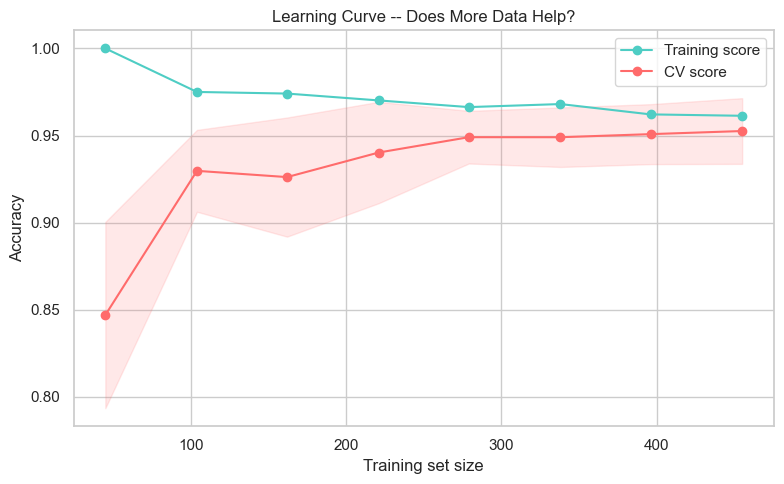

In [27]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(train_sizes, train_scores.mean(axis=1), marker="o", label="Training score", color="#4ecdc4")
ax.plot(train_sizes, val_scores.mean(axis=1), marker="o", label="CV score", color="#ff6b6b")
ax.fill_between(train_sizes, val_scores.mean(axis=1) - val_scores.std(axis=1),
                 val_scores.mean(axis=1) + val_scores.std(axis=1), alpha=0.15, color="#ff6b6b")
ax.set_xlabel("Training set size"); ax.set_ylabel("Accuracy")
ax.set_title("Learning Curve -- Does More Data Help?")
ax.legend()
plt.tight_layout()
plt.show()


## 14. `cross_validate` — Multiple Metrics at Once

`cross_validate` (distinct from `cross_val_score`) returns multiple scoring metrics and fit/score timing in one call — the practical tool once accuracy alone isn't the only thing worth tracking (full metric definitions in the next topic, Evaluation Metrics).


In [28]:
cv_results = cross_validate(
    LogisticRegression(max_iter=5000), X, y, cv=5,
    scoring=["accuracy", "precision", "recall", "f1"],
    return_train_score=True
)


In [29]:
results_summary = pd.DataFrame({
    metric: [cv_results[f"test_{metric}"].mean(), cv_results[f"test_{metric}"].std()]
    for metric in ["accuracy", "precision", "recall", "f1"]
}, index=["mean", "std"])
results_summary


,accuracy,precision,recall,f1
mean,0.950800,0.954262,0.96921,0.961188
std,0.018041,0.028609,0.02239,0.014032


## 15. Real Application — Choosing K

There's no single universally correct $K$; the notebook checks how the CV estimate's mean and std actually shift as $K$ grows on this real dataset, connecting directly to the README's bias-variance discussion of $K$ choice.


In [30]:
k_values = [3, 5, 10, 20]
k_results = []
for k in k_values:
    scores = cross_val_score(LogisticRegression(max_iter=5000), X, y, cv=StratifiedKFold(k, shuffle=True, random_state=42))
    k_results.append({"k": k, "mean": scores.mean(), "std": scores.std(), "n_fits": k})

pd.DataFrame(k_results)


,k,mean,std,n_fits
0,3,0.954312,0.008917,3
1,5,0.954339,0.018684,5
2,10,0.949123,0.029825,10
3,20,0.950924,0.037340,20


## ✅ Key Takeaways

- A single train/test split is a **noisy** performance estimate — the same model on the same data can swing several percentage points depending purely on the random split (section 2).
- **K-Fold CV** averages over $K$ splits, using every point for testing exactly once — the manual implementation matched scikit-learn's `cross_val_score` almost exactly.
- **StratifiedKFold** is the correct default for classification — it removes fold-composition class-imbalance noise that plain `KFold` can introduce.
- **LOOCV** maximizes training data per fold but costs $n$ model fits — only practical on small datasets.
- **Nested CV** is the theoretically correct choice whenever you both tune hyperparameters and report a final score — using one CV loop for both can leak information and inflate the reported number, though the size of that inflation depends on data size and hyperparameter search width (section 11 found it small on this particular clean, large dataset — still worth the insurance on smaller or noisier data).
- **TimeSeriesSplit** exists because shuffling time-ordered data is a real, common leakage bug — training must always precede testing chronologically.
- Cross-validation with **shared folds** is the correct way to compare different algorithms fairly — it removes which-fold-got-which-points as a confound.

**Next up:** [02_Hyperparameter_Tuning](../02_Hyperparameter_Tuning/) — using cross-validation systematically to search for the best hyperparameters, not just evaluate one fixed configuration.
